## Calcolo della luminosità della BLR

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1. Costanti e parametri
# =========================
c = 2.99792458e10
G = 6.67430e-8
h = 6.62607015e-27
kB = 1.380649e-16
sigma = 5.670374419e-5
Msun = 1.98847e33

eta = 0.083
Nr = 2000
Nnu = 400
nu_min = 1e13
nu_max = 1e17

file_linee = "Tab_completa_revisione.csv"
file_transizioni = "dati.asc"

SCENARI = [
    {"scenario": "MBH_5e8_lambda_0.01", "MBH_solar": 5e8, "lambda_edd": 0.01},
    {"scenario": "MBH_5e8_lambda_0.1",  "MBH_solar": 5e8, "lambda_edd": 0.1},
    {"scenario": "MBH_1e9_lambda_0.01", "MBH_solar": 1e9, "lambda_edd": 0.01},
    {"scenario": "MBH_1e9_lambda_0.1",  "MBH_solar": 1e9, "lambda_edd": 0.1},
]

# %%
# =========================
# 2. Funzioni utili
# =========================
def trova_colonna(df, possibili_nomi, obbligatoria=True):
    for nome in possibili_nomi:
        if nome in df.columns:
            return nome
    if obbligatoria:
        raise ValueError(f"Non trovo nessuna di queste colonne: {possibili_nomi}")
    return None


def costruisci_spettro_disco(MBH_solar, lambda_edd, eta=0.083, Nr=2000, Nnu=400,
                             nu_min=1e13, nu_max=1e17):
    MBH = MBH_solar * Msun
    Ledd = 1.3e38 * MBH_solar
    Ldisk = lambda_edd * Ledd
    Mdot = Ldisk / (eta * c**2)

    Rs = 2 * G * MBH / c**2
    Rin = 3 * Rs
    Rout = 3000 * Rs
    R = np.logspace(np.log10(Rin), np.log10(Rout), Nr)

    f = 1.0 - np.sqrt(Rin / R)
    f = np.clip(f, 0.0, None)
    T = ((3 * G * MBH * Mdot) / (8 * np.pi * sigma * R**3) * f)**0.25

    nu = np.logspace(np.log10(nu_min), np.log10(nu_max), Nnu)

    Bnu = np.zeros((Nnu, Nr))
    for j in range(Nr):
        if T[j] <= 0:
            continue
        x = h * nu / (kB * T[j])
        x = np.clip(x, 1e-12, 700.0)
        Bnu[:, j] = (2 * h * nu**3 / c**2) / (np.exp(x) - 1.0)

    integrand = R[None, :] * Bnu
    I_nu = np.trapezoid(integrand, R, axis=1)
    Lnu = 4 * np.pi**2 * I_nu
    nuLnu = nu * Lnu

    info = {
        "MBH_solar": MBH_solar,
        "Ledd": Ledd,
        "Ldisk": Ldisk,
        "Mdot": Mdot,
        "Rs": Rs,
        "Rin": Rin,
        "Rout": Rout
    }
    return nu, Lnu, nuLnu, info


def leggi_transizioni(file_transizioni):
    names, Eion, nu_ion_list = np.genfromtxt(
        file_transizioni,
        dtype=("U50", float, float),
        unpack=True
    )

    return pd.DataFrame({
        "line_name": names,
        "E_ion": Eion,
        "nu_ion": nu_ion_list
    })


def calcola_lion_per_transizioni(nu, Lnu, df_trans, nu_max=1e17):
    risultati = []

    for _, row in df_trans.iterrows():
        line_name = row["line_name"]
        E_ion = row["E_ion"]
        nu_ion = row["nu_ion"]

        if nu_ion >= nu_max:
            L_ion = 0.0
        else:
            mask = (nu >= nu_ion) & (nu <= nu_max)
            if np.sum(mask) < 2:
                L_ion = 0.0
            else:
                L_ion = np.trapezoid(Lnu[mask], nu[mask])

        risultati.append({
            "line_name": line_name,
            "E_ion": E_ion,
            "nu_ion": nu_ion,
            "L_ion": L_ion
        })

    return pd.DataFrame(risultati)


def estrai_linee_osservate(row, norm_columns):
    risultati = []

    for col in norm_columns:
        valore = row[col]
        if pd.isna(valore) or valore <= 0:
            continue

        line_name = col.replace("_norm", "")
        L_line = valore * 1e42

        risultati.append({
            "line_name": line_name,
            "norm_value": valore,
            "L_line": L_line
        })

    return pd.DataFrame(risultati)


def analizza_blazar(row, df_trans, norm_columns, verbose=False):
    MBH_solar = row["MBH_solar"]
    lambda_edd = row["lambda_edd"]

    nu, Lnu, nuLnu, info = costruisci_spettro_disco(
        MBH_solar=MBH_solar,
        eta=eta,
        lambda_edd=lambda_edd,
        Nr=Nr,
        Nnu=Nnu,
        nu_min=nu_min,
        nu_max=nu_max
    )

    df_lion = calcola_lion_per_transizioni(nu, Lnu, df_trans, nu_max=nu_max)
    df_linee = estrai_linee_osservate(row, norm_columns)

    df_conf = df_linee.merge(df_lion, on="line_name", how="left")
    df_conf["covering_factor"] = df_conf["L_line"] / df_conf["L_ion"]
    df_conf.loc[
        (df_conf["L_ion"].isna()) | (df_conf["L_ion"] <= 0),
        "covering_factor"
    ] = np.nan

    if verbose:
        print(row["label"])
        print(df_conf[["line_name", "L_line", "L_ion", "covering_factor"]])

    return df_conf

# %%
# =========================
# 3. Lettura dei file
# =========================
df_tab = pd.read_csv(file_linee)
df_trans = leggi_transizioni(file_transizioni)

col_name_tab = trova_colonna(df_tab, ["label", "file_name", "name", "nome", "blazar"])
norm_columns = [col for col in df_tab.columns if col.endswith("_norm")]

df_all = df_tab.rename(columns={col_name_tab: "label"}).copy()

# %%
# =========================
# 4. Covering factor per tutti i blazar e tutti gli scenari
# =========================
tutti_risultati_scenari = []

for scenario in SCENARI:
    df_all_scenario = df_all.copy()
    df_all_scenario["MBH_solar"] = scenario["MBH_solar"]
    df_all_scenario["lambda_edd"] = scenario["lambda_edd"]
    df_all_scenario["scenario"] = scenario["scenario"]

    risultati_scenario = []

    for i in range(len(df_all_scenario)):
        row = df_all_scenario.iloc[i]
        df_conf = analizza_blazar(
            row,
            df_trans,
            norm_columns,
            verbose=False
        )

        df_conf["label"] = row["label"]
        df_conf["scenario"] = scenario["scenario"]
        df_conf["MBH_solar"] = scenario["MBH_solar"]
        df_conf["lambda_edd"] = scenario["lambda_edd"]

        risultati_scenario.append(df_conf)

    df_risultati_scenario = pd.concat(risultati_scenario, ignore_index=True)
    tutti_risultati_scenari.append(df_risultati_scenario)

df_risultati_finali = pd.concat(tutti_risultati_scenari, ignore_index=True)

print("Prime righe di df_risultati_finali:")
display(df_risultati_finali.head())

Prime righe di df_risultati_finali:


,line_name,norm_value,L_line,E_ion,nu_ion,L_ion,covering_factor,label,scenario,MBH_solar,lambda_edd
0,Ha,3.631777,3.631777e+42,1.89,4.600000e+14,5.287321e+44,0.006869,J1745.6,MBH_5e8_lambda_0.01,500000000.0,0.01
1,Hb,1.103068,1.103068e+42,2.55,6.200000e+14,4.781810e+44,0.002307,J1745.6,MBH_5e8_lambda_0.01,500000000.0,0.01
2,Hb,6.569277,6.569277e+42,2.55,6.200000e+14,4.781810e+44,0.013738,J0021.6-6835,MBH_5e8_lambda_0.01,500000000.0,0.01
3,Hg,1.867612,1.867612e+42,2.86,6.910000e+14,4.546675e+44,0.004108,J0021.6-6835,MBH_5e8_lambda_0.01,500000000.0,0.01
4,Hd,1.343418,1.343418e+42,3.02,7.370000e+14,4.394148e+44,0.003057,J0021.6-6835,MBH_5e8_lambda_0.01,500000000.0,0.01


In [2]:
# =========================
# 5. Parte BLR: pesi di Vanden Berk
# =========================
BLR_WEIGHTS_VANDENBERK = {
    "CIV": 25.291,
    "CIII": 15.943,
    "MgII": 14.725,
    "Hd": 1.066,
    "Hg": 2.616,
    "Hb": 8.649,
    "Ha": 30.832
}

BLR_TOTAL_VANDENBERK = 264.197


# =========================
# 6. Stima L_BLR per singola linea
# =========================
# L_line non dipende dallo scenario, quindi elimino i duplicati
df_lblr_linee = df_risultati_finali[["label", "line_name", "L_line"]].copy()
df_lblr_linee = df_lblr_linee.drop_duplicates()

df_lblr_linee["w_i"] = df_lblr_linee["line_name"].map(BLR_WEIGHTS_VANDENBERK)
df_lblr_linee = df_lblr_linee[df_lblr_linee["w_i"].notna()].copy()

df_lblr_linee["L_BLR_i"] = (
    df_lblr_linee["L_line"] * BLR_TOTAL_VANDENBERK / df_lblr_linee["w_i"]
)

print("Tabella delle singole stime di L_BLR per linea:")
display(df_lblr_linee)


# =========================
# 7. Stima finale di L_BLR per blazar
# =========================
df_lblr_finale = (
    df_lblr_linee
    .groupby("label", as_index=False)
    .agg(
        n_linee_BLR=("line_name", "size"),
        linee_usate=("line_name", lambda x: ", ".join(x)),
        L_BLR_mean=("L_BLR_i", "mean")
    )
)

print("Tabella finale con L_BLR per ciascun blazar:")
display(df_lblr_finale)


Tabella delle singole stime di L_BLR per linea:


,label,line_name,L_line,w_i,L_BLR_i
0,J1745.6,Ha,3.631777e+42,30.832,3.112042e+43
1,J1745.6,Hb,1.103068e+42,8.649,3.369490e+43
2,J0021.6-6835,Hb,6.569277e+42,8.649,2.006687e+44
3,J0021.6-6835,Hg,1.867612e+42,2.616,1.886152e+44
4,J0021.6-6835,Hd,1.343418e+42,1.066,3.329522e+44
5,J0050.0-4458,Ha,3.335316e+41,30.832,2.858006e+42
6,J0050.0-4458,Hb,6.686534e+40,8.649,2.042505e+42
7,J0050.0-4458,Hg,5.502976e+40,2.616,5.557606e+42
8,J0050.0-4458,Hd,1.004694e+40,1.066,2.490028e+42
9,J0508.2-1936,CIV,4.174072e+44,25.291,4.360355e+45


Tabella finale con L_BLR per ciascun blazar:


,label,n_linee_BLR,linee_usate,L_BLR_mean
0,J0021.6-6835,3,"Hb, Hg, Hd",2.407453e+44
1,J0050.0-4458,4,"Ha, Hb, Hg, Hd",3.237036e+42
2,J0059.1-5701,3,"MgII, Hg, Hd",3.356903e+45
3,J0133.2-5159,2,"MgII, Hd",2.908294e+45
4,J0508.2-1936,2,"CIV, CIII",2.763102e+45
5,J0922.8-3959,4,"MgII, Hb, Hg, Hd",3.085932e+45
6,J1123.3-2529,4,"Ha, Hb, Hg, Hd",1.151137e+44
7,J1329.4-0530,3,"MgII, Hg, Hd",4.173302e+45
8,J152422.56,3,"MgII, CIII, Hd",1.959071e+43
9,J170108.89,3,"MgII, CIV, CIII",4.295690e+42


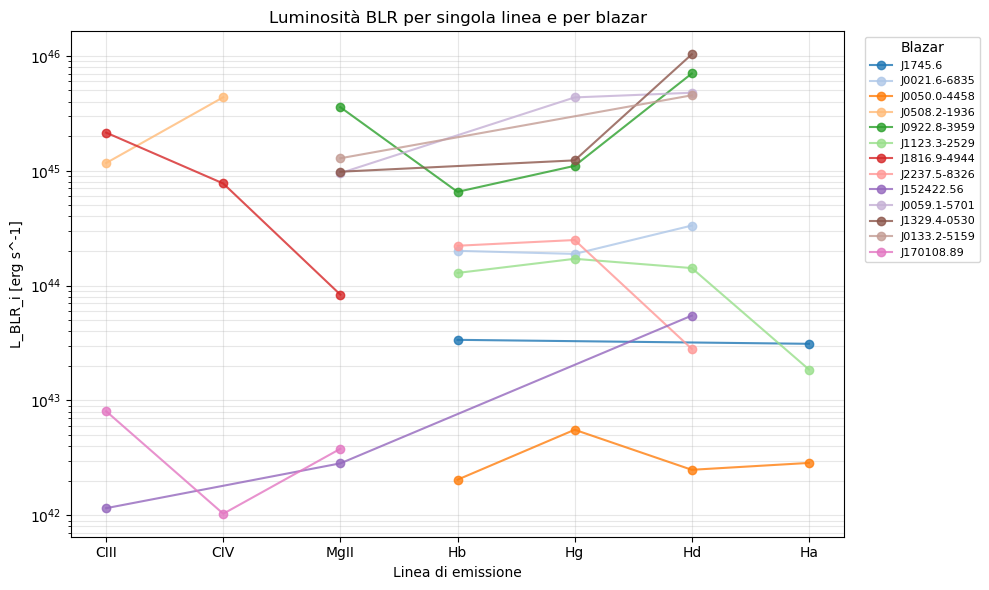

In [3]:
# =========================
# 8. Grafico L_BLR_i per linea e per blazar
# =========================
df_plot = df_lblr_linee.copy()
df_plot = df_plot[
    df_plot["L_BLR_i"].notna() &
    (df_plot["L_BLR_i"] > 0)
].copy()

ordine_linee = ["CIII", "CIV", "MgII", "Hb", "Hg", "Hd", "Ha"]
linee_presenti = df_plot["line_name"].unique().tolist()
linee_ordinate = [l for l in ordine_linee if l in linee_presenti]
linee_ordinate += [l for l in sorted(linee_presenti) if l not in linee_ordinate]

x_map = {linea: i for i, linea in enumerate(linee_ordinate)}

fig, ax = plt.subplots(figsize=(10, 6))

blazar_list = df_plot["label"].unique().tolist()
cmap = plt.get_cmap("tab20")
color_map = {blazar: cmap(i) for i, blazar in enumerate(blazar_list)}

for blazar in blazar_list:
    df_b = df_plot[df_plot["label"] == blazar].copy()

    if df_b.empty:
        continue

    df_b["x"] = df_b["line_name"].map(x_map)
    df_b = df_b.sort_values("x")

    ax.plot(
        df_b["x"],
        df_b["L_BLR_i"],
        marker="o",
        linewidth=1.5,
        markersize=6,
        color=color_map[blazar],
        alpha=0.8,
        label=blazar
    )

ax.set_xticks(range(len(linee_ordinate)))
ax.set_xticklabels(linee_ordinate)
ax.set_yscale("log")
ax.set_xlabel("Linea di emissione")
ax.set_ylabel("L_BLR_i [erg s^-1]")
ax.set_title("Luminosità BLR per singola linea e per blazar")
ax.grid(True, which="both", alpha=0.3)

ax.legend(
    title="Blazar",
    fontsize=8,
    loc="upper left",
    bbox_to_anchor=(1.02, 1)
)

plt.tight_layout()
plt.show()

Tabella riassuntiva per L_BLR media:


,label,L_BLR_mean,L_BLR_std,L_BLR_median,n_linee_BLR,linee_usate
0,J0050.0-4458,3.237036e+42,1.582575e+42,2.674017e+42,4,"Ha, Hb, Hg, Hd"
1,J170108.89,4.295690e+42,3.539998e+42,3.796247e+42,3,"MgII, CIV, CIII"
2,J152422.56,1.959071e+43,3.048989e+43,2.834239e+42,3,"MgII, CIII, Hd"
3,J1745.6,3.240766e+43,1.820436e+42,3.240766e+43,2,"Ha, Hb"
4,J1123.3-2529,1.151137e+44,6.671185e+43,1.354318e+44,4,"Ha, Hb, Hg, Hd"
5,J2237.5-8326,1.664891e+44,1.206005e+44,2.221921e+44,3,"Hb, Hg, Hd"
6,J0021.6-6835,2.407453e+44,8.008055e+43,2.006687e+44,3,"Hb, Hg, Hd"
7,J1816.9-4944,1.000999e+45,1.049843e+45,7.738245e+44,3,"MgII, CIV, CIII"
8,J0508.2-1936,2.763102e+45,2.258857e+45,2.763102e+45,2,"CIV, CIII"
9,J0133.2-5159,2.908294e+45,2.297712e+45,2.908294e+45,2,"MgII, Hd"


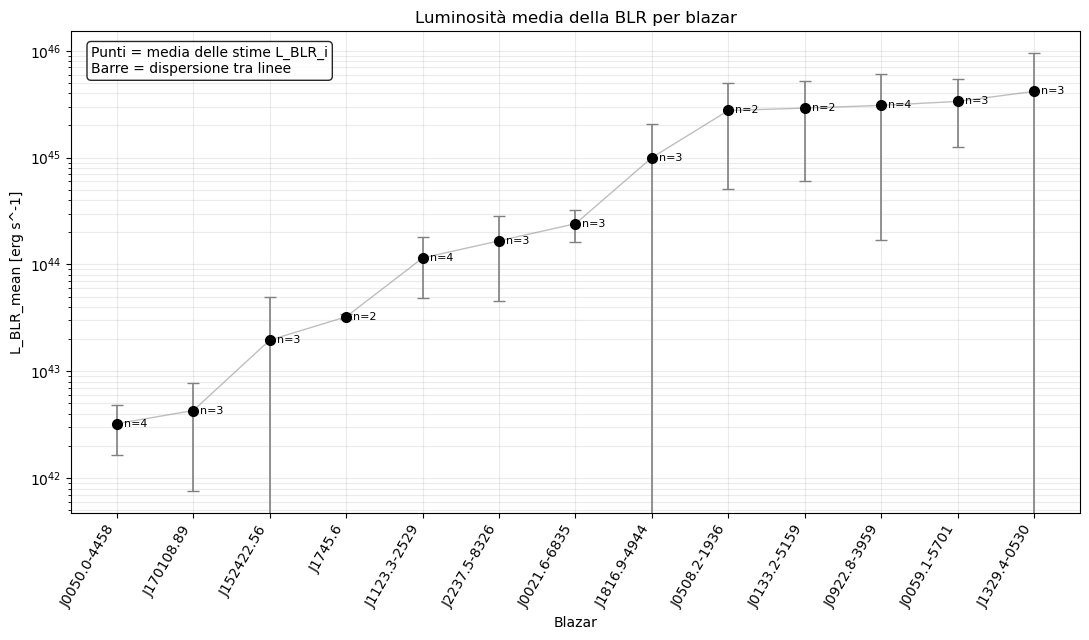

In [4]:
# =========================
# 9. Grafico L_BLR media per blazar
# =========================
df_plot = df_lblr_linee.copy()
df_plot = df_plot[
    df_plot["L_BLR_i"].notna() &
    (df_plot["L_BLR_i"] > 0)
].copy()

df_lblr_plot = (
    df_plot
    .groupby("label", as_index=False)
    .agg(
        L_BLR_mean=("L_BLR_i", "mean"),
        L_BLR_std=("L_BLR_i", "std"),
        L_BLR_median=("L_BLR_i", "median"),
        n_linee_BLR=("L_BLR_i", "count"),
        linee_usate=("line_name", lambda x: ", ".join(x))
    )
)

df_lblr_plot["L_BLR_std"] = df_lblr_plot["L_BLR_std"].fillna(0.0)
df_lblr_plot = df_lblr_plot.sort_values("L_BLR_mean").reset_index(drop=True)

print("Tabella riassuntiva per L_BLR media:")
display(df_lblr_plot)

fig, ax = plt.subplots(figsize=(11, 6.5))

x = np.arange(len(df_lblr_plot))
y = df_lblr_plot["L_BLR_mean"].values
yerr = df_lblr_plot["L_BLR_std"].values

ax.errorbar(
    x, y,
    yerr=yerr,
    fmt="o",
    markersize=7,
    capsize=4,
    linewidth=1.2,
    color="black",
    ecolor="gray",
    elinewidth=1.2,
    zorder=3
)

ax.plot(
    x, y,
    color="gray",
    alpha=0.5,
    linewidth=1.0,
    zorder=2
)

for i, row in df_lblr_plot.iterrows():
    ax.text(
        i,
        row["L_BLR_mean"],
        f"  n={int(row['n_linee_BLR'])}",
        fontsize=8,
        va="center",
        ha="left"
    )

ax.set_xticks(x)
ax.set_xticklabels(df_lblr_plot["label"], rotation=60, ha="right")
ax.set_yscale("log")
ax.set_ylabel("L_BLR_mean [erg s^-1]")
ax.set_xlabel("Blazar")
ax.set_title("Luminosità media della BLR per blazar")
ax.grid(True, which="both", alpha=0.25)

ax.text(
    0.02, 0.97,
    "Punti = media delle stime L_BLR_i\nBarre = dispersione tra linee",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=10,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.85)
)

plt.tight_layout()
plt.show()


###  calcolo del fattore f=L_blr/L_disk

In [5]:
# =========================
# 10. Confronto L_BLR e L_disk
# =========================
df_scenari = pd.DataFrame(SCENARI).copy()
df_scenari["Ledd"] = 1.3e38 * df_scenari["MBH_solar"]
df_scenari["Ldisk"] = df_scenari["lambda_edd"] * df_scenari["Ledd"]

df_lblr_ldisk = df_lblr_finale.merge(df_scenari, how="cross")
df_lblr_ldisk["f=L_BLR/Ldisk"] = df_lblr_ldisk["L_BLR_mean"] / df_lblr_ldisk["Ldisk"]

print("Tabella completa L_BLR + Ldisk:")
display(df_lblr_ldisk)

Tabella completa L_BLR + Ldisk:


,label,n_linee_BLR,linee_usate,L_BLR_mean,scenario,MBH_solar,lambda_edd,Ledd,Ldisk,f=L_BLR/Ldisk
0,J0021.6-6835,3,"Hb, Hg, Hd",2.407453e+44,MBH_5e8_lambda_0.01,5.000000e+08,0.01,6.500000e+46,6.500000e+44,0.370377
1,J0021.6-6835,3,"Hb, Hg, Hd",2.407453e+44,MBH_5e8_lambda_0.1,5.000000e+08,0.10,6.500000e+46,6.500000e+45,0.037038
2,J0021.6-6835,3,"Hb, Hg, Hd",2.407453e+44,MBH_1e9_lambda_0.01,1.000000e+09,0.01,1.300000e+47,1.300000e+45,0.185189
3,J0021.6-6835,3,"Hb, Hg, Hd",2.407453e+44,MBH_1e9_lambda_0.1,1.000000e+09,0.10,1.300000e+47,1.300000e+46,0.018519
4,J0050.0-4458,4,"Ha, Hb, Hg, Hd",3.237036e+42,MBH_5e8_lambda_0.01,5.000000e+08,0.01,6.500000e+46,6.500000e+44,0.004980
5,J0050.0-4458,4,"Ha, Hb, Hg, Hd",3.237036e+42,MBH_5e8_lambda_0.1,5.000000e+08,0.10,6.500000e+46,6.500000e+45,0.000498
6,J0050.0-4458,4,"Ha, Hb, Hg, Hd",3.237036e+42,MBH_1e9_lambda_0.01,1.000000e+09,0.01,1.300000e+47,1.300000e+45,0.002490
7,J0050.0-4458,4,"Ha, Hb, Hg, Hd",3.237036e+42,MBH_1e9_lambda_0.1,1.000000e+09,0.10,1.300000e+47,1.300000e+46,0.000249
8,J0059.1-5701,3,"MgII, Hg, Hd",3.356903e+45,MBH_5e8_lambda_0.01,5.000000e+08,0.01,6.500000e+46,6.500000e+44,5.164467
9,J0059.1-5701,3,"MgII, Hg, Hd",3.356903e+45,MBH_5e8_lambda_0.1,5.000000e+08,0.10,6.500000e+46,6.500000e+45,0.516447


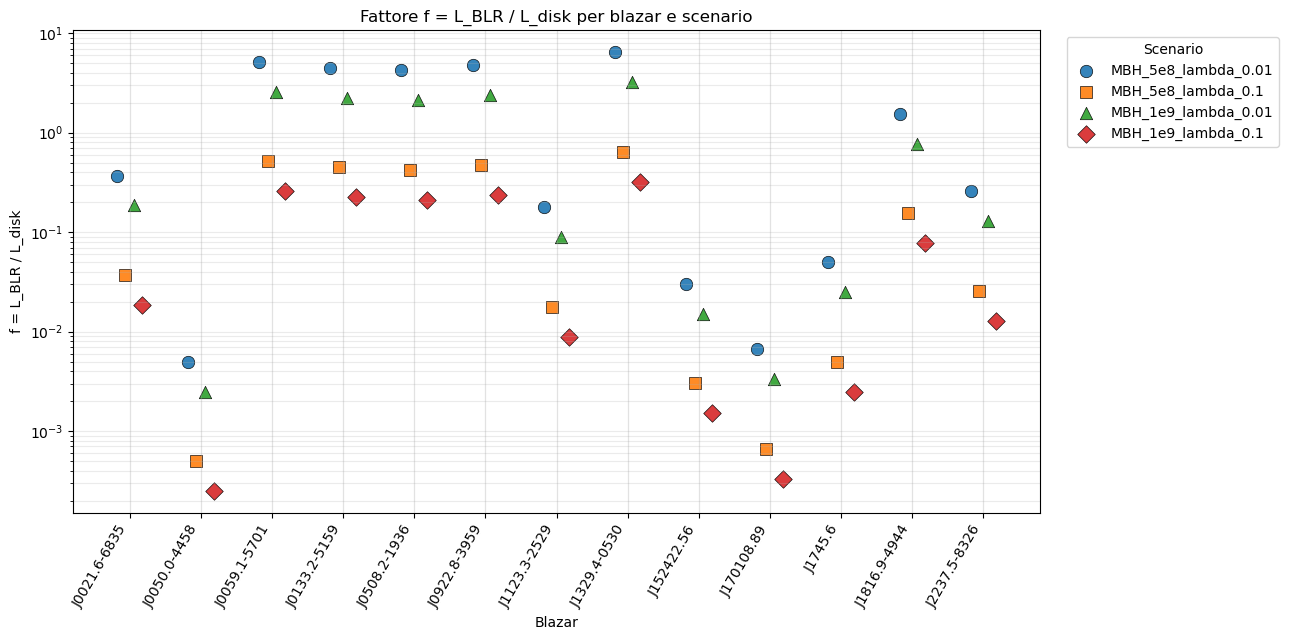

In [6]:
# =========================
# 11. Grafico del fattore f = L_BLR / L_disk
# =========================

df_f = df_lblr_ldisk.copy()

df_f = df_f[
    df_f["f=L_BLR/Ldisk"].notna() &
    (df_f["f=L_BLR/Ldisk"] > 0)
].copy()

ordine_scenari = [s["scenario"] for s in SCENARI]
blazar_unici = df_f["label"].drop_duplicates().tolist()

# posizione x dei blazar
x_map = {blazar: i for i, blazar in enumerate(blazar_unici)}

# piccoli offset per separare i 4 scenari
offset_map = {
    "MBH_5e8_lambda_0.01": -0.18,
    "MBH_5e8_lambda_0.1":  -0.06,
    "MBH_1e9_lambda_0.01":  0.06,
    "MBH_1e9_lambda_0.1":   0.18,
}

# marker per scenario
marker_map = {
    "MBH_5e8_lambda_0.01": "o",
    "MBH_5e8_lambda_0.1":  "s",
    "MBH_1e9_lambda_0.01": "^",
    "MBH_1e9_lambda_0.1":  "D",
}

# colori per scenario
color_map = {
    "MBH_5e8_lambda_0.01": "tab:blue",
    "MBH_5e8_lambda_0.1":  "tab:orange",
    "MBH_1e9_lambda_0.01": "tab:green",
    "MBH_1e9_lambda_0.1":  "tab:red",
}

df_f["x_base"] = df_f["label"].map(x_map)
df_f["x"] = df_f["x_base"] + df_f["scenario"].map(offset_map)

fig, ax = plt.subplots(figsize=(13, 6.5))

# punti
for scenario in ordine_scenari:
    df_s = df_f[df_f["scenario"] == scenario].copy()

    if df_s.empty:
        continue

    ax.scatter(
        df_s["x"],
        df_s["f=L_BLR/Ldisk"],
        color=color_map[scenario],
        marker=marker_map[scenario],
        s=80,
        edgecolors="black",
        linewidths=0.5,
        alpha=0.9,
        label=scenario
    )

# linee verticali leggere per separare i blazar
for i in range(len(blazar_unici)):
    ax.axvline(i, color="gray", alpha=0.08, lw=1)

ax.set_xticks(range(len(blazar_unici)))
ax.set_xticklabels(blazar_unici, rotation=60, ha="right")

ax.set_yscale("log")
ax.set_xlabel("Blazar")
ax.set_ylabel("f = L_BLR / L_disk")
ax.set_title("Fattore f = L_BLR / L_disk per blazar e scenario")
ax.grid(True, which="both", alpha=0.25)

ax.legend(title="Scenario", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

/tmp/ipykernel_16102/4089481216.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


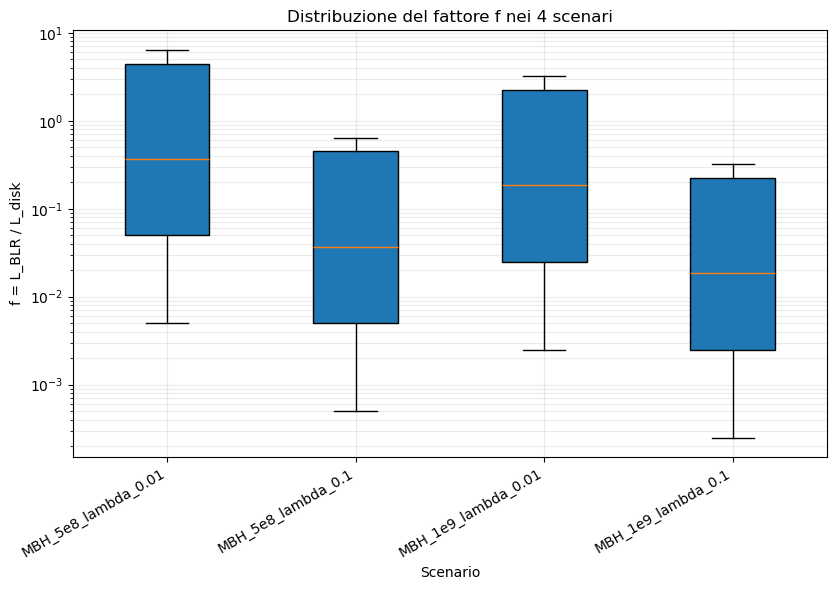

In [7]:
# =========================
# 12. Distribuzione di f nei 4 scenari
# =========================

fig, ax = plt.subplots(figsize=(8.5, 6))

data_box = [
    df_f[df_f["scenario"] == scenario]["f=L_BLR/Ldisk"].values
    for scenario in ordine_scenari
]

ax.boxplot(
    data_box,
    labels=ordine_scenari,
    patch_artist=True
)

ax.set_yscale("log")
ax.set_ylabel("f = L_BLR / L_disk")
ax.set_xlabel("Scenario")
ax.set_title("Distribuzione del fattore f nei 4 scenari")
ax.grid(True, which="both", alpha=0.25)
plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.show()

### confronto tra covering factor e L_blr

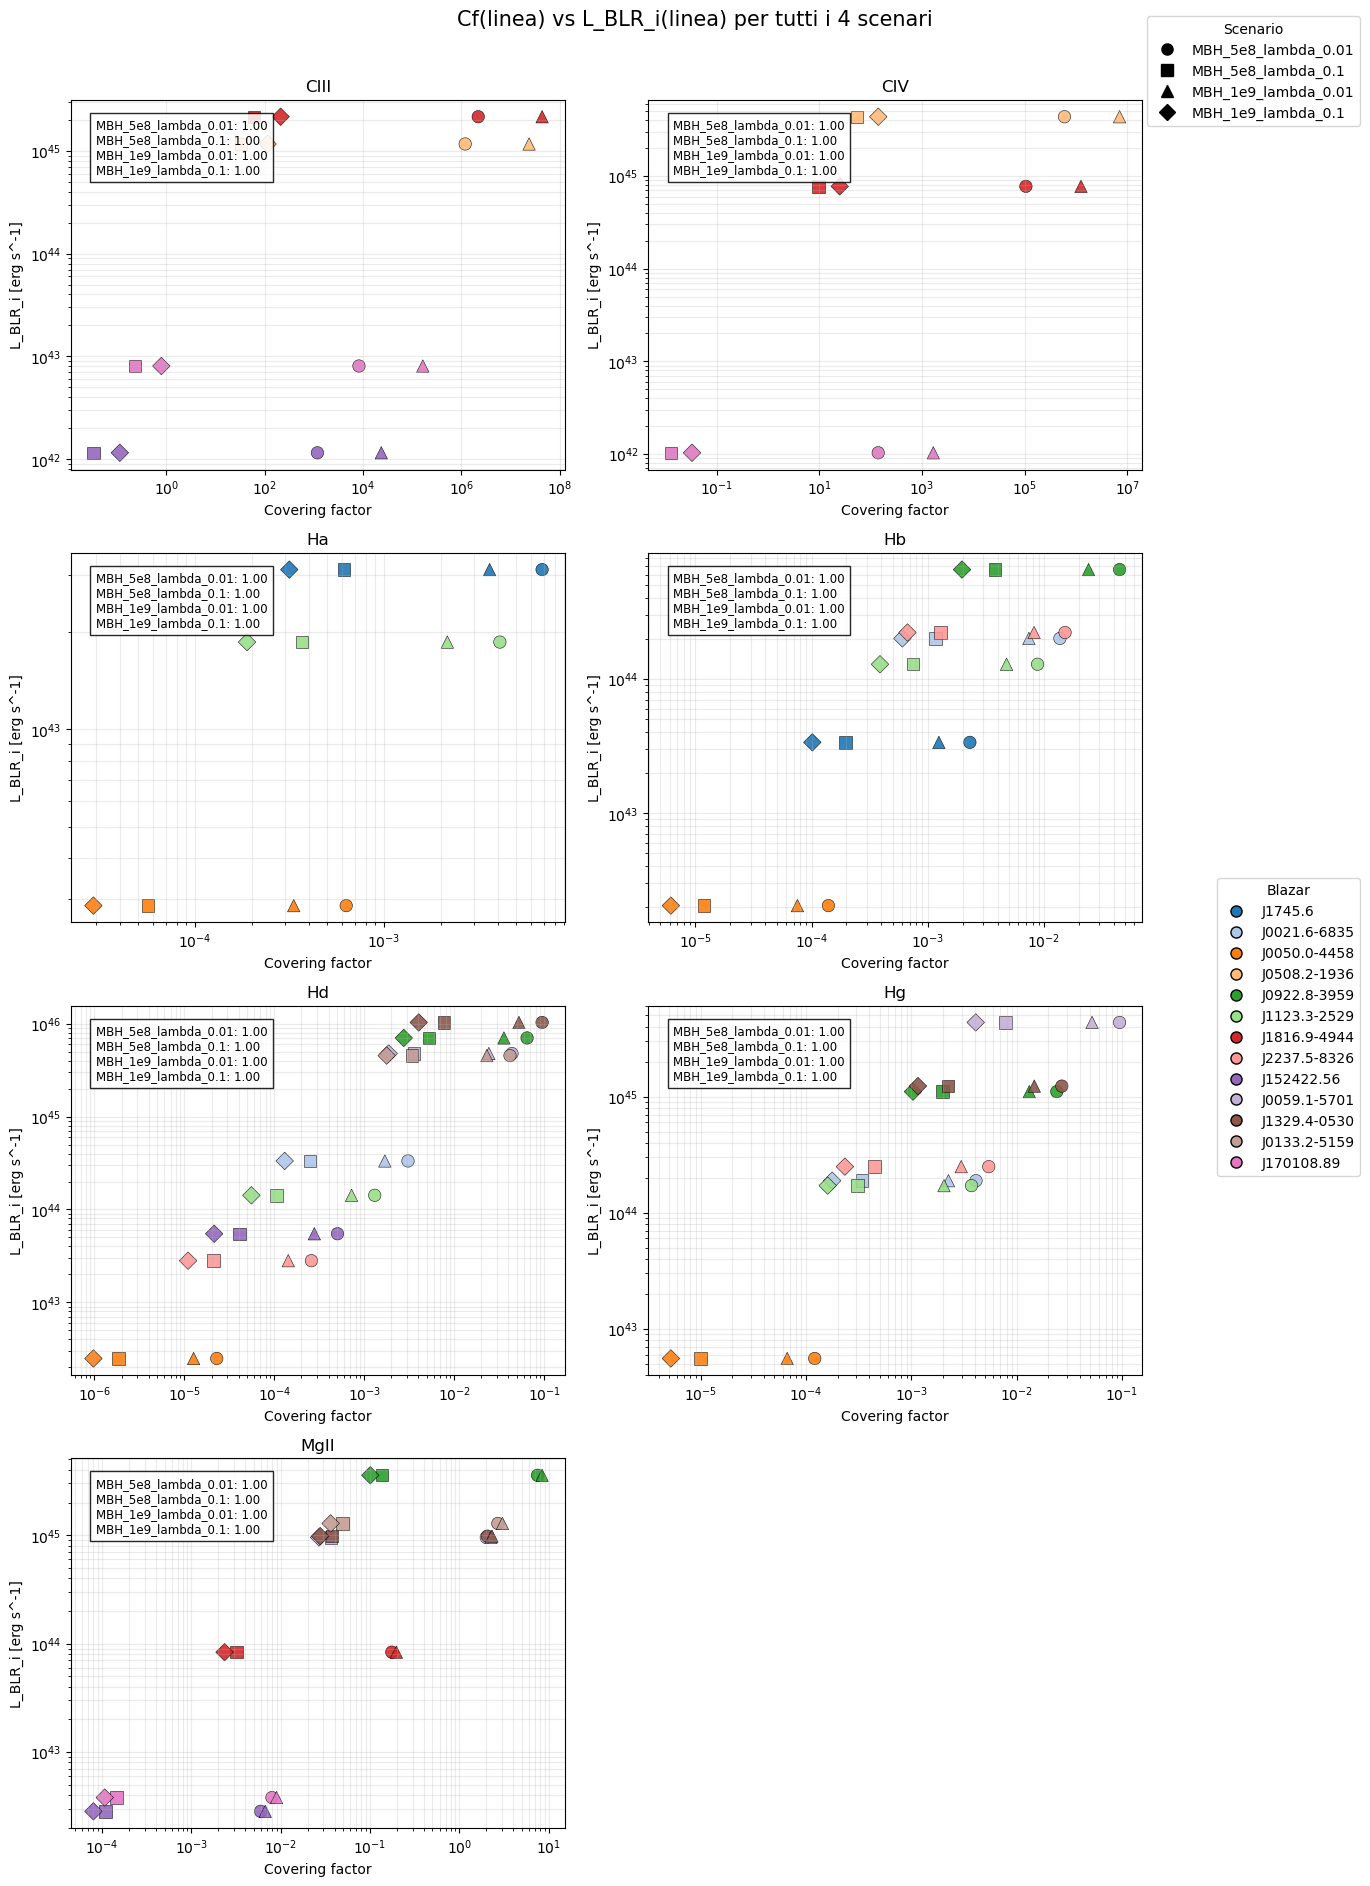

In [8]:
# =========================
# Cf(linea) vs L_BLR_i(linea) per tutti i 4 scenari
# - un pannello per ogni linea
# - marker = scenario
# - colore = blazar
# - legenda blazar fuori dal grafico
# - 4 Pearson per pannello, uno per scenario
# =========================

from matplotlib.lines import Line2D

# 1. Covering factor validi per tutti gli scenari
df_cf_line = df_risultati_finali.copy()

df_cf_line["covering_factor"] = pd.to_numeric(df_cf_line["covering_factor"], errors="coerce")

df_cf_line = df_cf_line[
    df_cf_line["covering_factor"].notna() &
    (df_cf_line["covering_factor"] > 0)
].copy()

# 2. Stime di L_BLR_i per singola linea
df_lblr_line = df_lblr_linee.copy()

df_lblr_line["L_BLR_i"] = pd.to_numeric(df_lblr_line["L_BLR_i"], errors="coerce")
df_lblr_line = df_lblr_line[
    df_lblr_line["L_BLR_i"].notna() &
    (df_lblr_line["L_BLR_i"] > 0)
].copy()

# 3. Merge su blazar + linea
df_line = df_cf_line.merge(
    df_lblr_line[["label", "line_name", "L_BLR_i"]],
    on=["label", "line_name"],
    how="inner"
)

# 4. Ordine linee
ordine_linee_preferito = ["CIII", "CIV", "Ha", "Hb", "Hd", "Hg", "MgII"]

linee_presenti = df_line["line_name"].dropna().unique().tolist()
linee_uniche = [l for l in ordine_linee_preferito if l in linee_presenti]
linee_uniche += [l for l in sorted(linee_presenti) if l not in linee_uniche]

# 5. Ordine scenari, marker e colori blazar
ordine_scenari = [s["scenario"] for s in SCENARI]

marker_map = {
    "MBH_5e8_lambda_0.01": "o",
    "MBH_5e8_lambda_0.1":  "s",
    "MBH_1e9_lambda_0.01": "^",
    "MBH_1e9_lambda_0.1":  "D",
}

blazar_unici = df_line["label"].drop_duplicates().tolist()
cmap = plt.get_cmap("tab20")
color_map_blazar = {blazar: cmap(i) for i, blazar in enumerate(blazar_unici)}

# 6. Layout pannelli
n_linee = len(linee_uniche)
ncols = 2
nrows = int(np.ceil(n_linee / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4.8 * nrows))
axes = np.array(axes).reshape(-1)

for ax, linea in zip(axes, linee_uniche):
    df_l = df_line[df_line["line_name"] == linea].copy()

    if len(df_l) < 2:
        ax.axis("off")
        continue

    # punti: marker = scenario, colore = blazar
    for scenario in ordine_scenari:
        df_s = df_l[df_l["scenario"] == scenario].copy()

        if df_s.empty:
            continue

        ax.scatter(
            df_s["covering_factor"],
            df_s["L_BLR_i"],
            s=80,
            c=[color_map_blazar[b] for b in df_s["label"]],
            marker=marker_map[scenario],
            edgecolors="black",
            linewidths=0.4,
            alpha=0.9
        )

    # Pearson separato per scenario
    pearson_lines = []
    for scenario in ordine_scenari:
        df_s = df_l[df_l["scenario"] == scenario].copy()

        if (
            len(df_s) >= 2 and
            df_s["covering_factor"].nunique() > 1 and
            df_s["L_BLR_i"].nunique() > 1
        ):
            pearson = df_s["covering_factor"].corr(df_s["L_BLR_i"], method="pearson")
            pearson_lines.append(f"{scenario}: {pearson:.2f}")
        else:
            pearson_lines.append(f"{scenario}: nan")

    ax.text(
        0.05, 0.95,
        "\n".join(pearson_lines),
        transform=ax.transAxes,
        va="top",
        fontsize=8.5,
        bbox=dict(facecolor="white", alpha=0.85)
    )

    ax.set_xscale("log")
    ax.set_yscale("log")

    ax.set_title(linea)
    ax.set_xlabel("Covering factor")
    ax.set_ylabel("L_BLR_i [erg s^-1]")
    ax.grid(True, which="both", alpha=0.25)

# spengo pannelli vuoti
for j in range(len(linee_uniche), len(axes)):
    axes[j].axis("off")

# =========================
# Legenda scenari (marker)
# =========================
legend_scenari = [
    Line2D([0], [0],
           marker=marker_map[scenario],
           color="black",
           linestyle="None",
           markersize=8,
           label=scenario)
    for scenario in ordine_scenari
]

leg1 = fig.legend(
    handles=legend_scenari,
    title="Scenario",
    loc="upper right",
    bbox_to_anchor=(0.98, 0.98)
)

# =========================
# Legenda blazar (colori)
# =========================
legend_blazar = [
    Line2D([0], [0],
           marker="o",
           color="w",
           markerfacecolor=color_map_blazar[blazar],
           markeredgecolor="black",
           markersize=8,
           label=blazar)
    for blazar in blazar_unici
]

leg2 = fig.legend(
    handles=legend_blazar,
    title="Blazar",
    loc="center right",
    bbox_to_anchor=(0.98, 0.45),
    ncol=1
)

fig.suptitle("Cf(linea) vs L_BLR_i(linea) per tutti i 4 scenari", fontsize=15)
plt.tight_layout(rect=[0, 0, 0.83, 0.97])
plt.show()

OTTENGO CHE : L_blr è direttamente proporzionale a C_f
   infatti matematicamente L_blr_i=(C*L_line_i)/(w_i)   
   da ciò ottengo : L_blr_i=(C*C_f*L_ion)/(w_i)

--> NON HO OTTENUTO NULLA DI FISICO, HO SOLO DIMOSTRATO CHE CODICE E' COERENTE


MBH_5e8_lambda_0.01 → Pearson = 0.1578
MBH_5e8_lambda_0.1 → Pearson = 0.2035
MBH_1e9_lambda_0.01 → Pearson = 0.1429
MBH_1e9_lambda_0.1 → Pearson = 0.1919


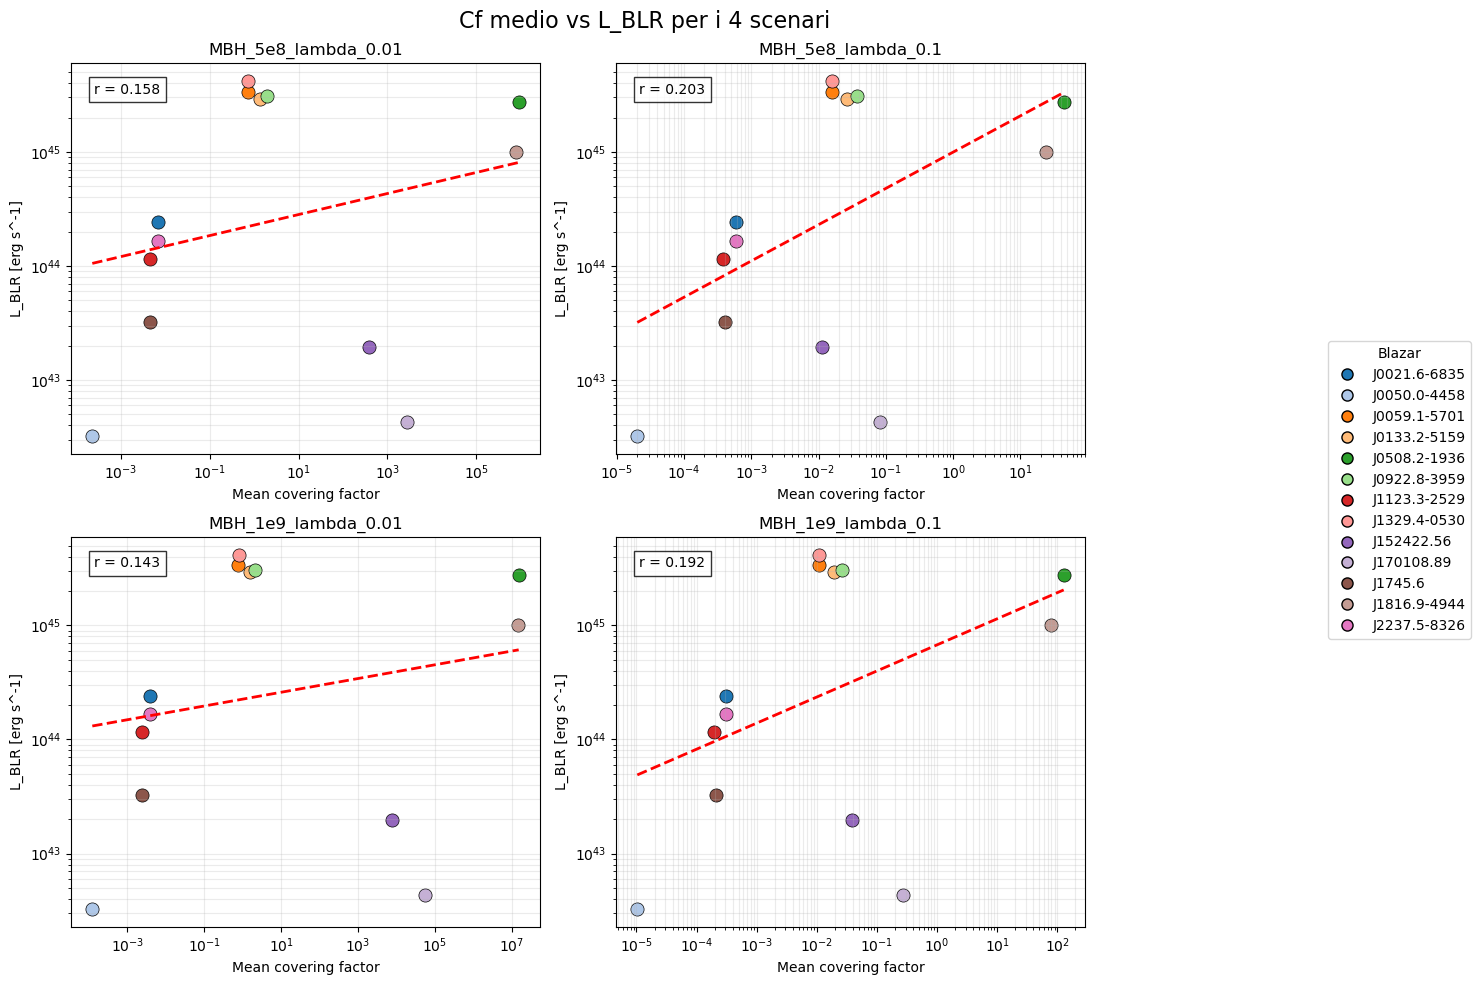

In [9]:
# =========================
# Cf medio vs L_BLR per i 4 scenari
# colori = blazar
# =========================

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()

# =========================
# colori per blazar
# =========================
blazar_list = df_lblr_finale["label"].drop_duplicates().tolist()
cmap = plt.get_cmap("tab20")
color_map = {blazar: cmap(i) for i, blazar in enumerate(blazar_list)}

for ax, scenario in zip(axes, SCENARI):

    nome_scenario = scenario["scenario"]

    # =========================
    # 1. Cf medio
    # =========================
    df_cf = df_risultati_finali.copy()

    df_cf["covering_factor"] = pd.to_numeric(df_cf["covering_factor"], errors="coerce")

    df_cf = df_cf[
        (df_cf["scenario"] == nome_scenario) &
        df_cf["covering_factor"].notna() &
        (df_cf["covering_factor"] > 0)
    ].copy()

    df_cf_mean = (
        df_cf
        .groupby("label", as_index=False)
        .agg(
            Cf_mean=("covering_factor", "mean"),
            Cf_std=("covering_factor", "std"),
            N_linee=("covering_factor", "count")
        )
    )

    # =========================
    # 2. Merge con L_BLR
    # =========================
    df_plot = df_cf_mean.merge(
        df_lblr_finale[["label", "L_BLR_mean"]],
        on="label",
        how="inner"
    )

    df_plot = df_plot[
        df_plot["L_BLR_mean"].notna() &
        (df_plot["L_BLR_mean"] > 0)
    ].copy()

    # =========================
    # 3. Pearson
    # =========================
    if (
        len(df_plot) >= 2 and
        df_plot["Cf_mean"].nunique() > 1 and
        df_plot["L_BLR_mean"].nunique() > 1
    ):
        pearson = df_plot["Cf_mean"].corr(df_plot["L_BLR_mean"], method="pearson")
    else:
        pearson = np.nan

    print(f"{nome_scenario} → Pearson = {pearson:.4f}")

    # =========================
    # 4. Scatter colorato
    # =========================
    for _, row in df_plot.iterrows():
        ax.scatter(
            row["Cf_mean"],
            row["L_BLR_mean"],
            color=color_map[row["label"]],
            s=90,
            edgecolors="black",
            linewidths=0.5
        )

    # =========================
    # 5. Fit log-log
    # =========================
    if (
        len(df_plot) >= 2 and
        np.all(df_plot["Cf_mean"] > 0) and
        np.all(df_plot["L_BLR_mean"] > 0)
    ):
        xlog = np.log10(df_plot["Cf_mean"])
        ylog = np.log10(df_plot["L_BLR_mean"])

        if np.unique(xlog).size > 1 and np.unique(ylog).size > 1:
            coeff = np.polyfit(xlog, ylog, 1)
            xx = np.linspace(xlog.min(), xlog.max(), 200)
            yy = coeff[0] * xx + coeff[1]

            ax.plot(
                10**xx,
                10**yy,
                color="red",
                linestyle="--",
                linewidth=2
            )

    # =========================
    # 6. Pearson box
    # =========================
    ax.text(
        0.05, 0.95,
        f"r = {pearson:.3f}" if pd.notna(pearson) else "r = nan",
        transform=ax.transAxes,
        va="top",
        fontsize=10,
        bbox=dict(facecolor="white", alpha=0.8)
    )

    # =========================
    # 7. Stile
    # =========================
    ax.set_xscale("log")
    ax.set_yscale("log")

    ax.set_xlabel("Mean covering factor")
    ax.set_ylabel("L_BLR [erg s^-1]")
    ax.set_title(nome_scenario)

    ax.grid(True, which="both", alpha=0.25)

# =========================
# Legenda blazar (fuori)
# =========================
from matplotlib.lines import Line2D

legend_elements = [
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        markerfacecolor=color_map[blazar],
        markeredgecolor='black',
        markersize=8,
        label=blazar
    )
    for blazar in blazar_list
]

fig.legend(
    handles=legend_elements,
    title="Blazar",
    bbox_to_anchor=(1.02, 0.5),
    loc="center left",
    ncol=1
)

# =========================
# Layout finale
# =========================
fig.suptitle("Cf medio vs L_BLR per i 4 scenari", fontsize=16)

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

OTTENGO CHE: non ho quasi nessuna correlazione lineare tra Cf medio e L_BLR
QUESTO PERCHE' ........ 

MBH_5e8_lambda_0.01 → Pearson = 0.1578
MBH_5e8_lambda_0.1 → Pearson = 0.2035
MBH_1e9_lambda_0.01 → Pearson = 0.1429
MBH_1e9_lambda_0.1 → Pearson = 0.1919


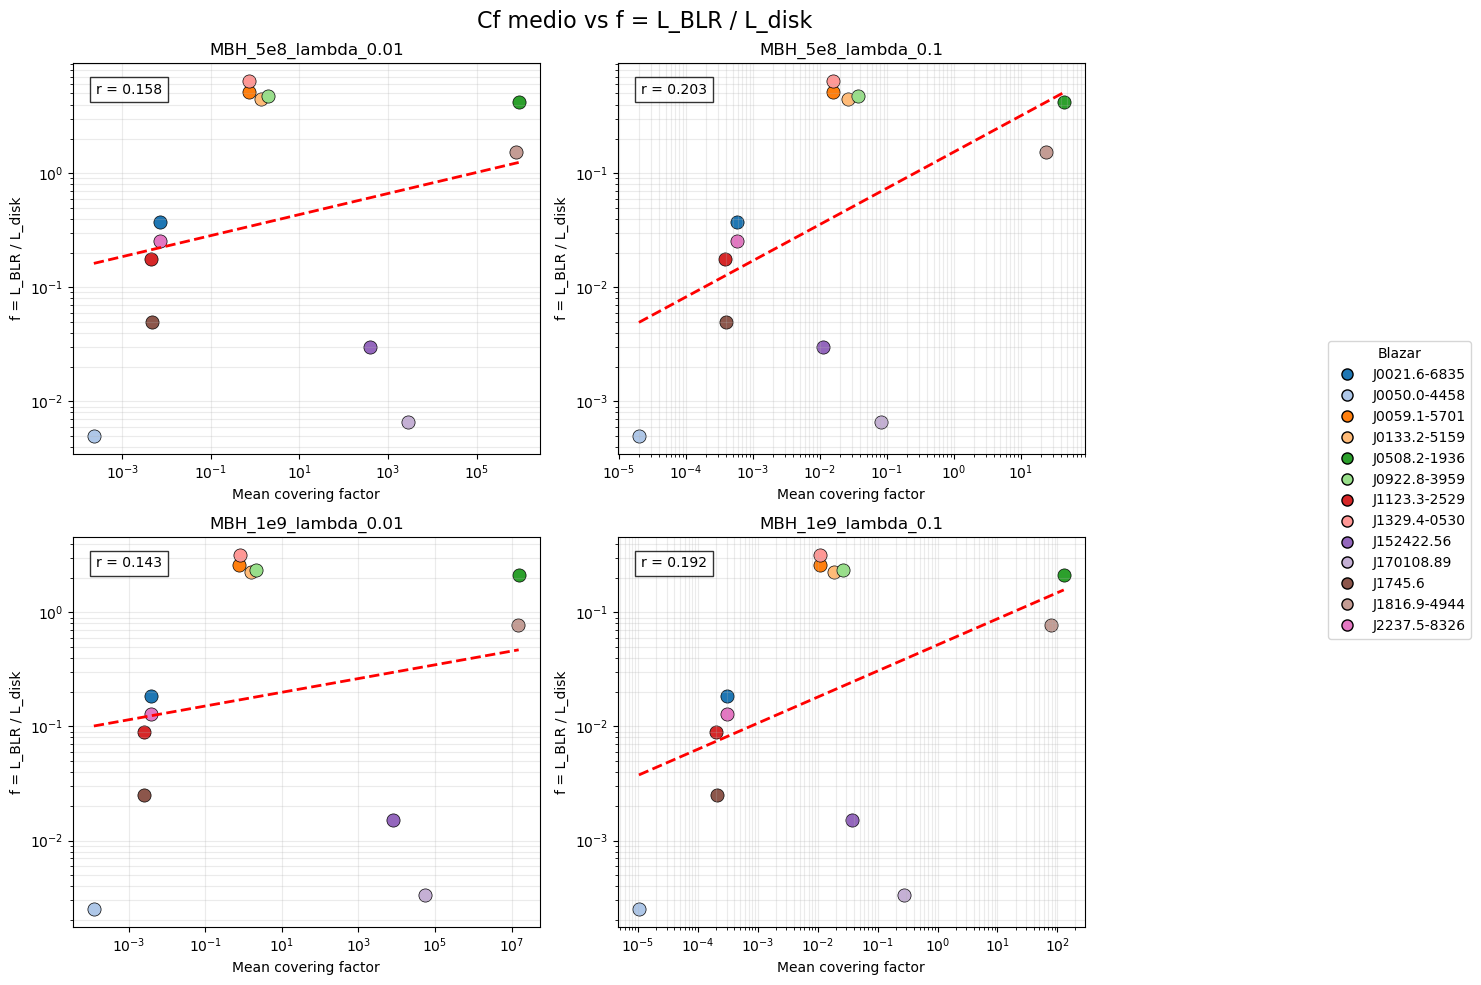

In [10]:
# =========================
# Cf medio vs f = L_BLR / L_disk
# per tutti i 4 scenari
#NB: Lion che sta in Cf è correlato con Ldisk
# =========================

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()

# colori per blazar
blazar_list = df_lblr_finale["label"].drop_duplicates().tolist()
cmap = plt.get_cmap("tab20")
color_map = {blazar: cmap(i) for i, blazar in enumerate(blazar_list)}

for ax, scenario in zip(axes, SCENARI):

    nome_scenario = scenario["scenario"]

    # =========================
    # 1. Cf medio
    # =========================
    df_cf = df_risultati_finali.copy()

    df_cf["covering_factor"] = pd.to_numeric(df_cf["covering_factor"], errors="coerce")

    df_cf = df_cf[
        (df_cf["scenario"] == nome_scenario) &
        df_cf["covering_factor"].notna() &
        (df_cf["covering_factor"] > 0)
    ].copy()

    df_cf_mean = (
        df_cf
        .groupby("label", as_index=False)
        .agg(
            Cf_mean=("covering_factor", "mean"),
            Cf_std=("covering_factor", "std"),
            N_linee=("covering_factor", "count")
        )
    )

    # =========================
    # 2. prendo f = L_BLR / L_disk
    # =========================
    df_f = df_lblr_ldisk[
        df_lblr_ldisk["scenario"] == nome_scenario
    ][["label", "f=L_BLR/Ldisk"]].copy()

    # =========================
    # 3. merge
    # =========================
    df_plot = df_cf_mean.merge(df_f, on="label", how="inner")

    df_plot["f=L_BLR/Ldisk"] = pd.to_numeric(df_plot["f=L_BLR/Ldisk"], errors="coerce")

    df_plot = df_plot[
        df_plot["Cf_mean"].notna() &
        df_plot["f=L_BLR/Ldisk"].notna() &
        (df_plot["Cf_mean"] > 0) &
        (df_plot["f=L_BLR/Ldisk"] > 0)
    ].copy()

    # =========================
    # 4. Pearson
    # =========================
    if (
        len(df_plot) >= 2 and
        df_plot["Cf_mean"].nunique() > 1 and
        df_plot["f=L_BLR/Ldisk"].nunique() > 1
    ):
        pearson = df_plot["Cf_mean"].corr(df_plot["f=L_BLR/Ldisk"], method="pearson")
    else:
        pearson = np.nan

    print(f"{nome_scenario} → Pearson = {pearson:.4f}")

    # =========================
    # 5. scatter colorato
    # =========================
    for _, row in df_plot.iterrows():
        ax.scatter(
            row["Cf_mean"],
            row["f=L_BLR/Ldisk"],
            color=color_map[row["label"]],
            s=90,
            edgecolors="black",
            linewidths=0.5
        )

    # =========================
    # 6. fit log-log
    # =========================
    if (
        len(df_plot) >= 2 and
        np.all(df_plot["Cf_mean"] > 0) and
        np.all(df_plot["f=L_BLR/Ldisk"] > 0)
    ):
        xlog = np.log10(df_plot["Cf_mean"])
        ylog = np.log10(df_plot["f=L_BLR/Ldisk"])

        if np.unique(xlog).size > 1 and np.unique(ylog).size > 1:
            coeff = np.polyfit(xlog, ylog, 1)
            xx = np.linspace(xlog.min(), xlog.max(), 200)
            yy = coeff[0] * xx + coeff[1]

            ax.plot(
                10**xx,
                10**yy,
                color="red",
                linestyle="--",
                linewidth=2,
                label=f"slope = {coeff[0]:.2f}"
            )

    # =========================
    # 7. box Pearson
    # =========================
    ax.text(
        0.05, 0.95,
        f"r = {pearson:.3f}" if pd.notna(pearson) else "r = nan",
        transform=ax.transAxes,
        va="top",
        fontsize=10,
        bbox=dict(facecolor="white", alpha=0.8)
    )

    # =========================
    # 8. stile
    # =========================
    ax.set_xscale("log")
    ax.set_yscale("log")

    ax.set_xlabel("Mean covering factor")
    ax.set_ylabel("f = L_BLR / L_disk")
    ax.set_title(nome_scenario)

    ax.grid(True, which="both", alpha=0.25)

# =========================
# legenda blazar (fuori)
# =========================
from matplotlib.lines import Line2D

legend_elements = [
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        markerfacecolor=color_map[blazar],
        markeredgecolor='black',
        markersize=8,
        label=blazar
    )
    for blazar in blazar_list
]

fig.legend(
    handles=legend_elements,
    title="Blazar",
    bbox_to_anchor=(1.02, 0.5),
    loc="center left"
)

# =========================
# layout finale
# =========================
fig.suptitle("Cf medio vs f = L_BLR / L_disk", fontsize=16)

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

OTTENGO CHE: 

In [12]:
from scipy.stats import spearmanr, kendalltau

# =========================
# Cf medio + f
# =========================
df_cf = df_risultati_finali.copy()

df_cf["covering_factor"] = pd.to_numeric(df_cf["covering_factor"], errors="coerce")

df_cf = df_cf[
    df_cf["covering_factor"].notna() &
    (df_cf["covering_factor"] > 0)
].copy()

df_cf_mean = (
    df_cf
    .groupby(["label", "scenario"], as_index=False)
    .agg(Cf_mean=("covering_factor", "mean"))
)

df_f = df_lblr_ldisk.copy()
df_f["f"] = pd.to_numeric(df_f["f=L_BLR/Ldisk"], errors="coerce")

df_f = df_f[
    df_f["f"].notna() &
    (df_f["f"] > 0)
].copy()

df_all_corr = df_cf_mean.merge(
    df_f[["label", "scenario", "f"]],
    on=["label", "scenario"],
    how="inner"
)

# =========================
# LOOP sugli scenari
# =========================
for scenario in SCENARI:
    nome = scenario["scenario"]

    df_s = df_all_corr[df_all_corr["scenario"] == nome]

    if len(df_s) < 3:
        continue

    x = df_s["Cf_mean"].values
    y = df_s["f"].values

    # Pearson
    pearson = np.corrcoef(x, y)[0,1]

    # Spearman
    spear, _ = spearmanr(x, y)

    # Kendall
    kend, _ = kendalltau(x, y)

    # Fit log-log
    xlog = np.log10(x)
    ylog = np.log10(y)

    slope, intercept = np.polyfit(xlog, ylog, 1)

    print("\n==========================")
    print(f"Scenario: {nome}")
    print(f"Pearson   r  = {pearson:.3f}")
    print(f"Spearman  ρ  = {spear:.3f}")
    print(f"Kendall   τ  = {kend:.3f}")
    print(f"Slope log-log = {slope:.3f}")


Scenario: MBH_5e8_lambda_0.01
Pearson   r  = 0.158
Spearman  ρ  = 0.286
Kendall   τ  = 0.231
Slope log-log = 0.092

Scenario: MBH_5e8_lambda_0.1
Pearson   r  = 0.203
Spearman  ρ  = 0.462
Kendall   τ  = 0.282
Slope log-log = 0.318

Scenario: MBH_1e9_lambda_0.01
Pearson   r  = 0.143
Spearman  ρ  = 0.286
Kendall   τ  = 0.231
Slope log-log = 0.060

Scenario: MBH_1e9_lambda_0.1
Pearson   r  = 0.192
Spearman  ρ  = 0.275
Kendall   τ  = 0.179
Slope log-log = 0.229


OTTENGO CHE: NON c’è una correlazione forte, ma dato che Spearman > Pearson --> relazione monotona ma non lineare ed inoltre slope > 0 --> tendenza crescente -->quando Cf aumenta anche f tende ad aumentare;
inoltre slope <<1 mi dice che cf ed f aumentano in  modo diverso